# Network Revival Neural EI Experiments

This notebook keeps only the cache-first analyses built on the Fig. 5 neural network: state-space node EI, EI-ranked ignition thresholds, Pair state-space synergy, and Pair co-ignition cost validation. The original Fig. 5 reproduction is intentionally not rerun here; cached EI artifacts are loaded when the manifest matches the visible configuration.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display, Image, Markdown

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'network_revival':
    REPO_ROOT = REPO_ROOT.parents[1]
elif REPO_ROOT.name == 'exp':
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from exp.network_revival.effective_information import (
    run_ei_ignition_threshold_experiment,
    run_pair_ignition_cost_experiment,
    run_state_space_node_ei,
    run_state_space_pair_synergy,
)
from exp.network_revival.notebook_reports import (
    image_paths_with_pdf,
    make_ignition_threshold_config,
    make_pair_ignition_cost_config,
    make_pair_synergy_config,
    make_state_space_config,
    plot_ignition_threshold_report,
    plot_pair_ignition_cost_report,
    plot_pair_synergy_report,
    plot_state_space_report,
    state_space_run_id,
    summarize_ignition_threshold_result,
    summarize_pair_ignition_cost_result,
    summarize_pair_synergy_result,
    summarize_state_space_result,
)

FIGURE_ROOT = REPO_ROOT / 'exp/network_revival/figures'


## Configuration

Edit only these knobs for the main neural EI experiment. `FORCE_RECOMPUTE=False` makes reruns load matching caches instead of recomputing the expensive state-space simulation or threshold search.

In [2]:
FORCE_RECOMPUTE = False

state_space_config = make_state_space_config(
    sample_count=10000,
    state_low=0.0,
    state_high=30.0,
    tau=20.0,
    dt=0.08,
    seed=42,
    batch_size=512,
    target_noise_fraction=0.01,
    win=20.0,
    wout=5.0,
    show_progress=True,
)

ignition_config = make_ignition_threshold_config(
    state_space_config,
    per_stratum=30,
    delta_low=0.0,
    delta_high=30.0,
    binary_steps=10,
    success_threshold=5.0,
    t_force=12.0,
    dt=0.08,
    tol_ss=2e-3,
    show_progress=True,
)

pair_synergy_config = make_pair_synergy_config(
    state_space_config,
    pair_count=200,
    pair_seed=42,
    show_progress=True,
)

pair_ignition_config = make_pair_ignition_cost_config(
    pair_synergy_config,
    cost_low=0.0,
    cost_high=60.0,
    single_delta_low=0.0,
    single_delta_high=30.0,
    binary_steps=10,
    success_threshold=5.0,
    t_force=12.0,
    dt=0.08,
    tol_ss=2e-3,
    show_progress=True,
)

STATE_SPACE_RUN_ID = state_space_run_id(state_space_config)
FIGURE_DIR = FIGURE_ROOT / STATE_SPACE_RUN_ID
EI_SUMMARY_CSV = state_space_config.output_dir / 'state_space_node_ei_summary.csv'
PAIR_SYNERGY_CSV = pair_synergy_config.output_dir / 'state_space_pair_synergy.csv'

print('Run ID:', STATE_SPACE_RUN_ID)
print('State-space output:', state_space_config.output_dir)
print('Ignition output:', ignition_config.output_dir)
print('Pair synergy output:', pair_synergy_config.output_dir)
print('Pair co-ignition output:', pair_ignition_config.output_dir)


Run ID: fig5l_state_wout5p0_win20p0_tau20p0_n10000_seed42
State-space output: /Users/yangmingzhe/Desktop/code/github/EISyn/results/network_revival_state_space_ei/fig5l_state_wout5p0_win20p0_tau20p0_n10000_seed42
Ignition output: /Users/yangmingzhe/Desktop/code/github/EISyn/results/network_revival_ei_ignition_threshold/fig5l_state_wout5p0_win20p0_tau20p0_n10000_seed42
Pair synergy output: /Users/yangmingzhe/Desktop/code/github/EISyn/results/network_revival_state_space_pair_synergy/fig5l_state_wout5p0_win20p0_tau20p0_n10000_seed42_pairs200_seed42
Pair co-ignition output: /Users/yangmingzhe/Desktop/code/github/EISyn/results/network_revival_pair_ignition_cost/fig5l_state_wout5p0_win20p0_tau20p0_n10000_seed42_pairs200_seed42


## State-space EI

Each sampled full network state is evolved freely to `tau`; EI ranks source nodes by how much their initial state informs the final whole-system state vector.

In [3]:
state_space_result = run_state_space_node_ei(state_space_config, force_recompute=FORCE_RECOMPUTE)
state_stats = summarize_state_space_result(state_space_result, top_k=30)

print('Samples NPZ:', state_space_result['cache_paths']['samples_npz'])
print('Summary CSV:', state_space_result['cache_paths']['summary_csv'])
print('Manifest:', state_space_result['cache_paths']['manifest_json'])
print('Loaded target:', state_space_result['manifest']['target_variable'])

display(state_stats['top_nodes'][['node', 'community', 'ei_final_state', 'rank_ei_final_state']])


State-space EI simulation samples 1-10000/10000 (n=889, tau=20.0, batch_size=512)
Samples NPZ: /Users/yangmingzhe/Desktop/code/github/EISyn/results/network_revival_state_space_ei/fig5l_state_wout5p0_win20p0_tau20p0_n10000_seed42/state_space_ei_samples.npz
Summary CSV: /Users/yangmingzhe/Desktop/code/github/EISyn/results/network_revival_state_space_ei/fig5l_state_wout5p0_win20p0_tau20p0_n10000_seed42/state_space_node_ei_summary.csv
Manifest: /Users/yangmingzhe/Desktop/code/github/EISyn/results/network_revival_state_space_ei/fig5l_state_wout5p0_win20p0_tau20p0_n10000_seed42/manifest.json
Loaded target: whole_system_state_at_tau


,node,community,ei_final_state,rank_ei_final_state
0,377,M1,0.088509,1
1,378,M1,0.078876,2
2,887,M2,0.000000,888


rank_top /Users/yangmingzhe/Desktop/code/github/EISyn/exp/network_revival/figures/fig5l_state_wout5p0_win20p0_tau20p0_n10000_seed42/fig5l_state_space_node_ei_rankings.png /Users/yangmingzhe/Desktop/code/github/EISyn/exp/network_revival/figures/fig5l_state_wout5p0_win20p0_tau20p0_n10000_seed42/fig5l_state_space_node_ei_rankings.pdf


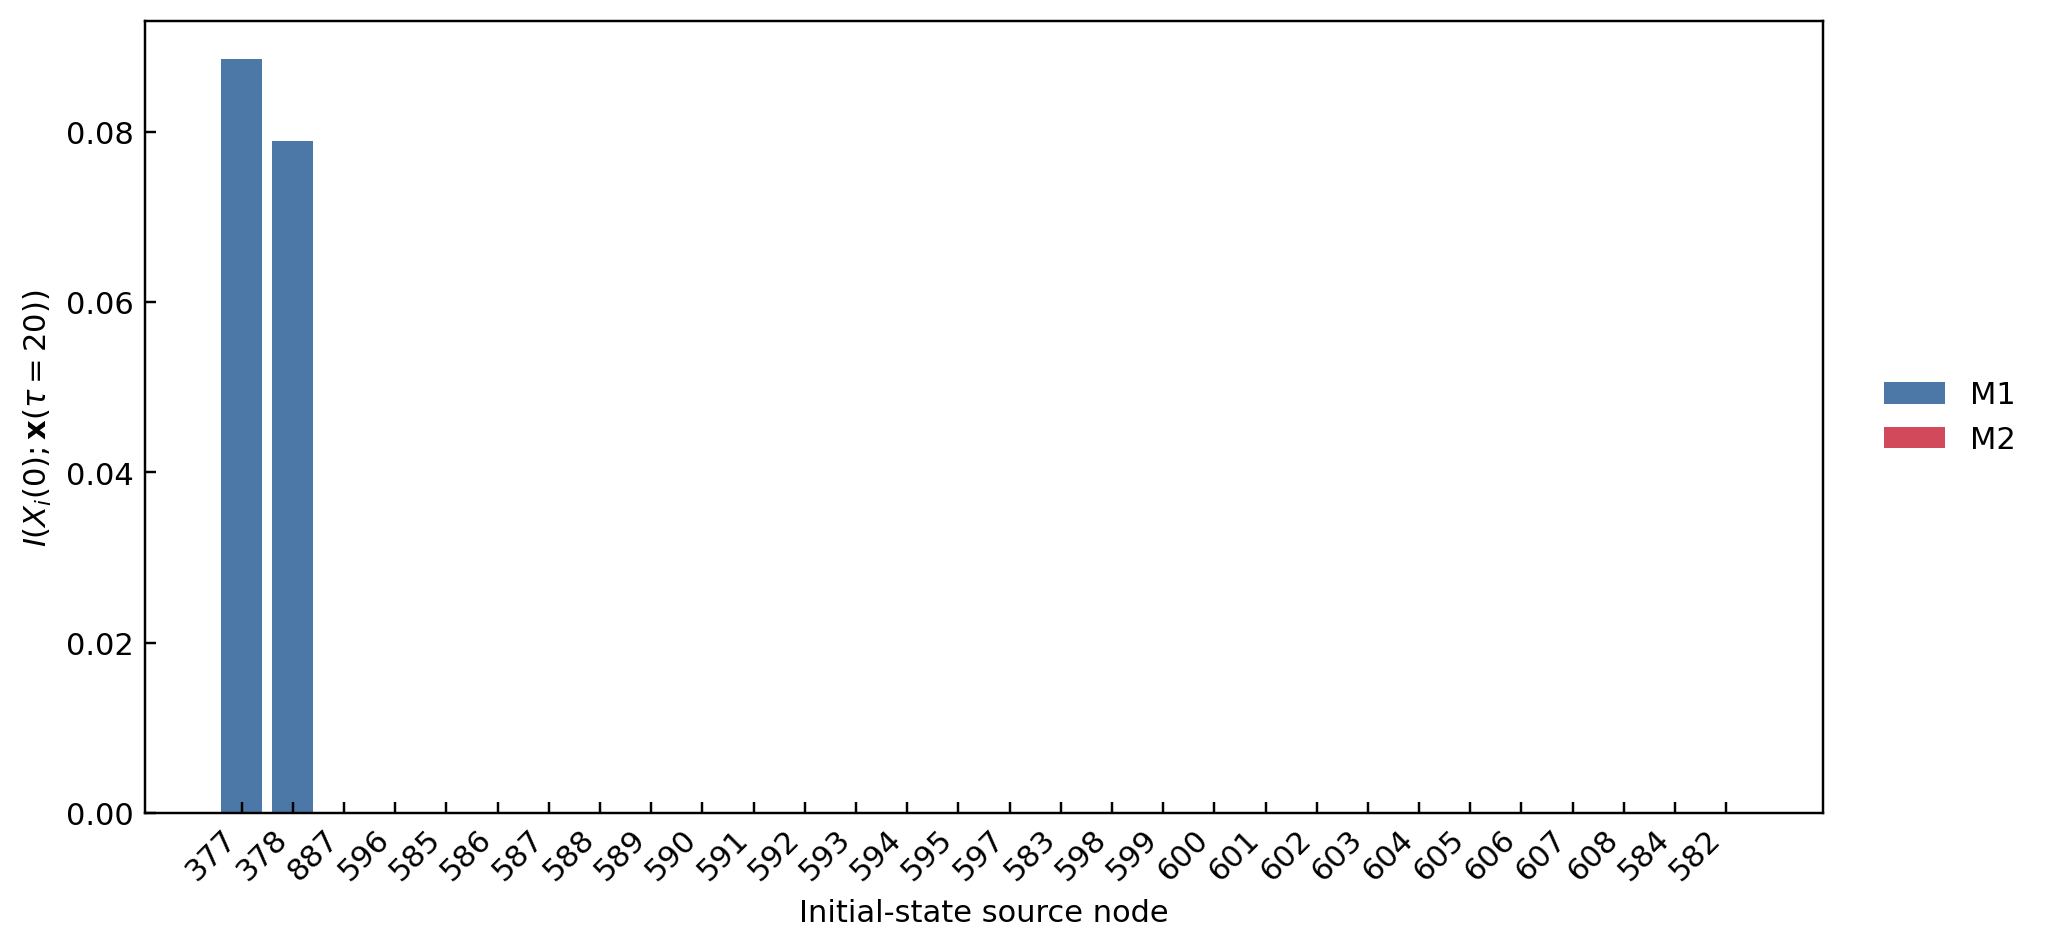

rank_tail /Users/yangmingzhe/Desktop/code/github/EISyn/exp/network_revival/figures/fig5l_state_wout5p0_win20p0_tau20p0_n10000_seed42/fig5l_state_space_node_ei_rankings_tail.png /Users/yangmingzhe/Desktop/code/github/EISyn/exp/network_revival/figures/fig5l_state_wout5p0_win20p0_tau20p0_n10000_seed42/fig5l_state_space_node_ei_rankings_tail.pdf


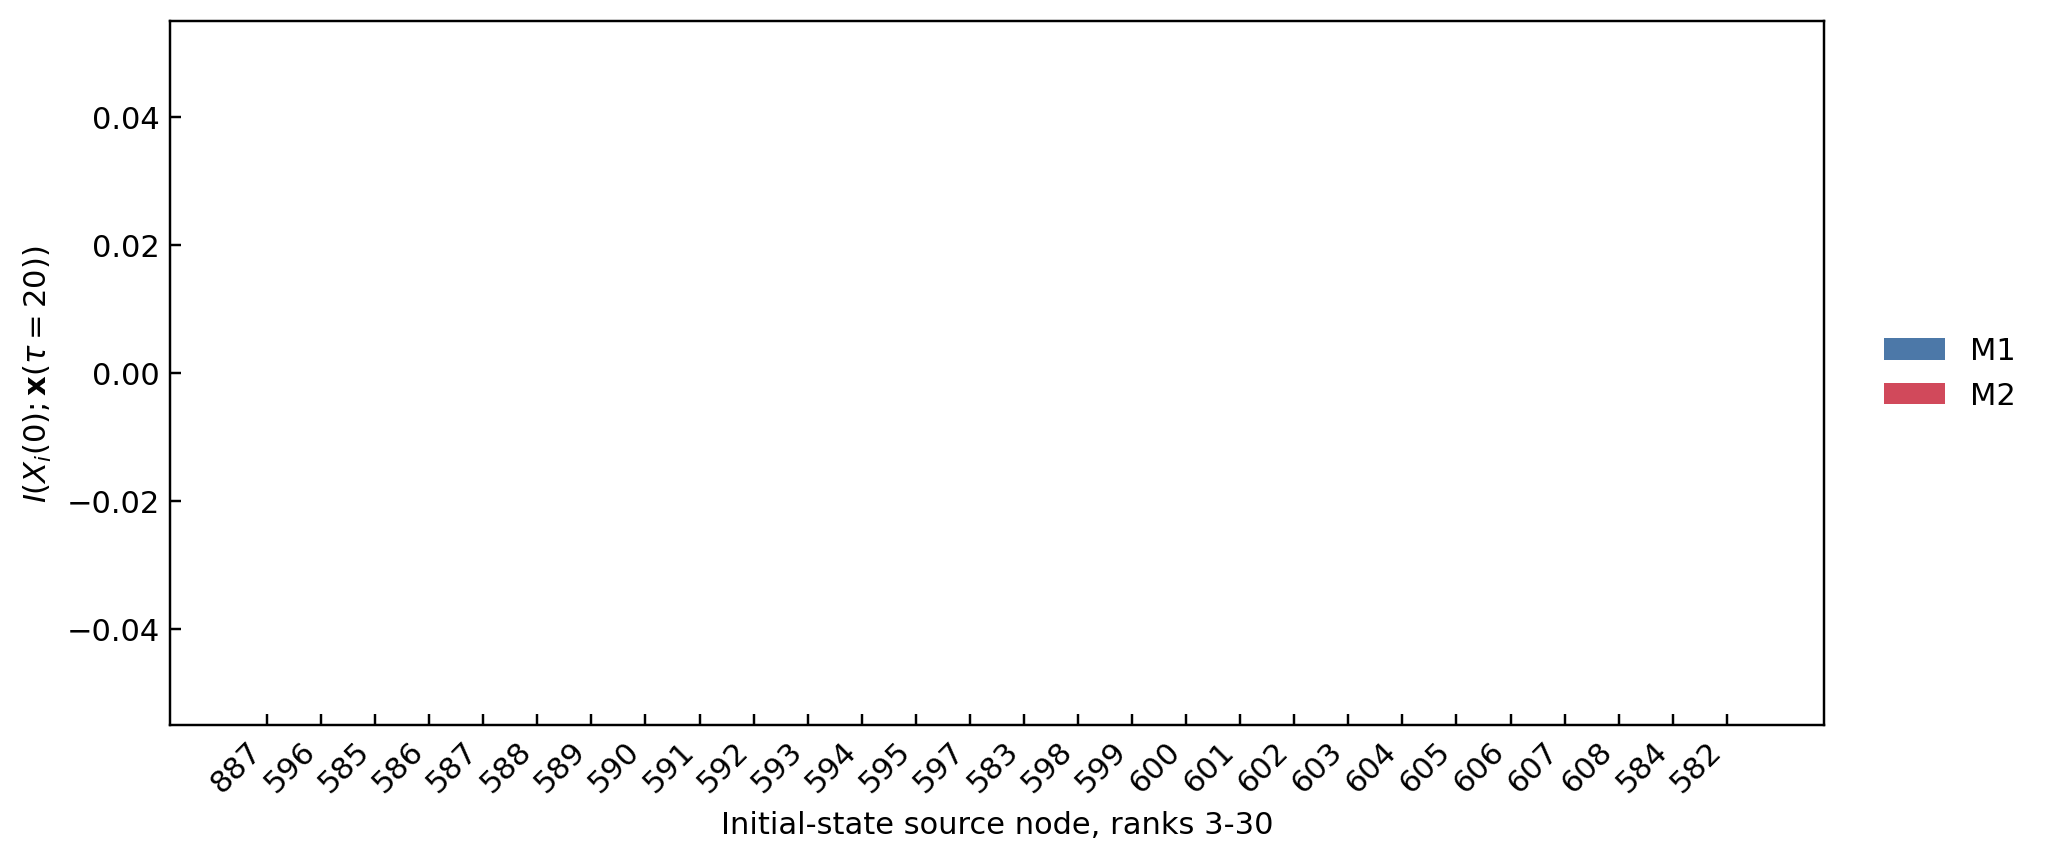

final_mean_hist /Users/yangmingzhe/Desktop/code/github/EISyn/exp/network_revival/figures/fig5l_state_wout5p0_win20p0_tau20p0_n10000_seed42/fig5l_state_space_final_mean_distribution.png /Users/yangmingzhe/Desktop/code/github/EISyn/exp/network_revival/figures/fig5l_state_wout5p0_win20p0_tau20p0_n10000_seed42/fig5l_state_space_final_mean_distribution.pdf


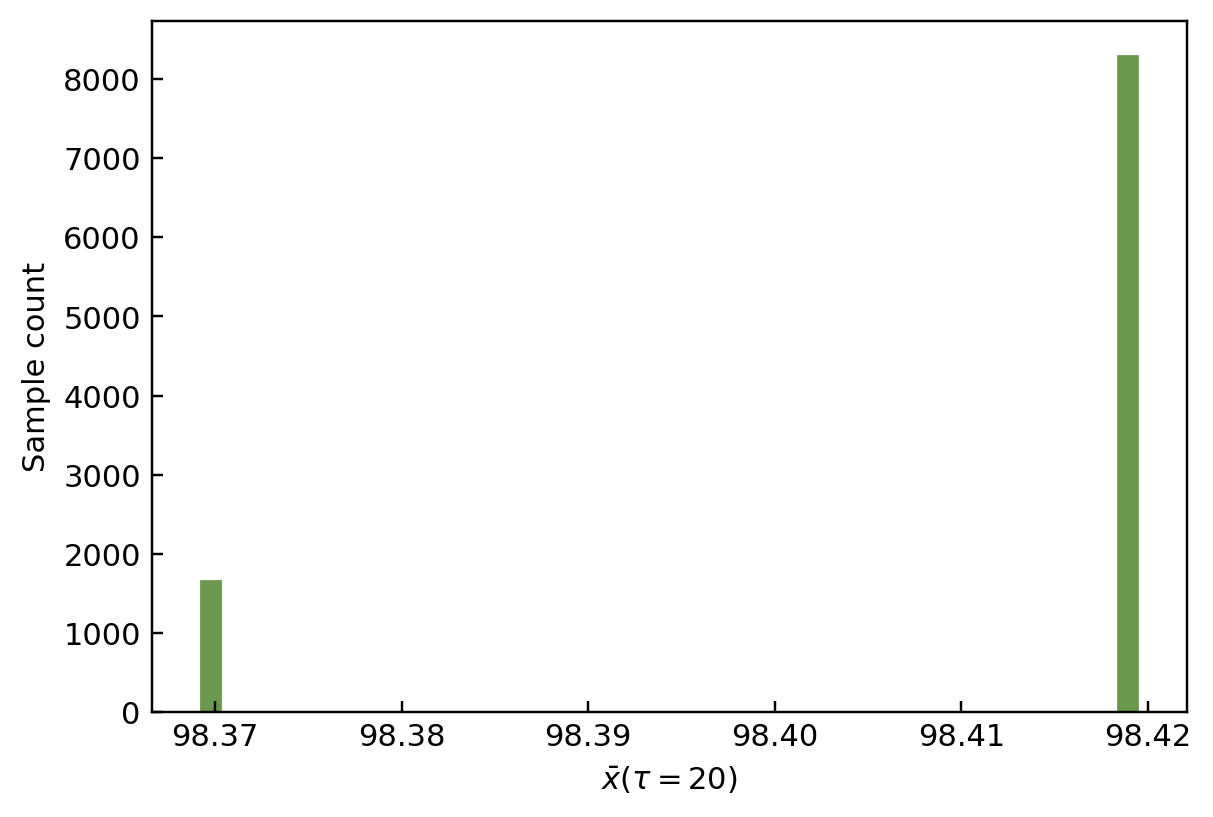


The top two state-space EI nodes are **377** (M1, EI=0.08851) and **378** (M1, EI=0.07888).
The third node is **887** (M2, EI=0), while the network-wide median EI is 0.
The final mean activity distribution spans 98.4 to 98.4; it is a diagnostic of sampled trajectories, not the EI target itself.


In [4]:
state_figure_paths = plot_state_space_report(state_space_result, state_space_config, FIGURE_DIR, top_k=30)
for name, (png_path, pdf_path) in image_paths_with_pdf(state_figure_paths).items():
    print(name, png_path, pdf_path)
    display(Image(filename=str(png_path)))

top = state_stats['top_nodes'].reset_index(drop=True)
first, second, third = top.iloc[0], top.iloc[1], top.iloc[2]
display(Markdown(f'''
The top two state-space EI nodes are **{int(first.node)}** ({first.community}, EI={first.ei_final_state:.4g}) and **{int(second.node)}** ({second.community}, EI={second.ei_final_state:.4g}).
The third node is **{int(third.node)}** ({third.community}, EI={third.ei_final_state:.4g}), while the network-wide median EI is {state_stats['median_ei']:.2g}.
The final mean activity distribution spans {state_stats['final_mean_min']:.3g} to {state_stats['final_mean_max']:.3g}; it is a diagnostic of sampled trajectories, not the EI target itself.
'''))


## EI-ranked ignition thresholds

This step reuses the state-space EI summary and tests whether top/middle/bottom EI strata require different fixed ignition amplitudes to recover both modules.

In [5]:
threshold_result = run_ei_ignition_threshold_experiment(
    ignition_config,
    ei_summary_csv=EI_SUMMARY_CSV,
    force_recompute=FORCE_RECOMPUTE,
)
threshold_stats = summarize_ignition_threshold_result(threshold_result, ignition_config)
threshold_df = threshold_stats['threshold']

print('Threshold CSV:', threshold_result['cache_paths']['threshold_csv'])
print('Samples NPZ:', threshold_result['cache_paths']['samples_npz'])
print('Manifest:', threshold_result['cache_paths']['manifest_json'])

display(threshold_df[['node', 'ei_stratum', 'ei_rank', 'ei_final_state', 'threshold_status', 'effective_delta']].head(20))
display(pd.DataFrame({
    'metric': ['finite_count', 'total_count', 'censored_rate', 'spearman_r', 'spearman_p'],
    'value': [
        threshold_stats['finite_count'],
        threshold_stats['total_count'],
        threshold_stats['censored_rate'],
        threshold_stats['spearman_r'],
        threshold_stats['spearman_p'],
    ],
}))


Ignition threshold node 1/90: 377
Ignition threshold node 2/90: 378
Ignition threshold node 3/90: 0
Ignition threshold node 4/90: 1
Ignition threshold node 5/90: 2
Ignition threshold node 6/90: 3
Ignition threshold node 7/90: 4
Ignition threshold node 8/90: 5
Ignition threshold node 9/90: 6
Ignition threshold node 10/90: 7
Ignition threshold node 11/90: 8
Ignition threshold node 12/90: 9
Ignition threshold node 13/90: 10
Ignition threshold node 14/90: 11
Ignition threshold node 15/90: 12
Ignition threshold node 16/90: 13
Ignition threshold node 17/90: 14
Ignition threshold node 18/90: 15
Ignition threshold node 19/90: 16
Ignition threshold node 20/90: 17
Ignition threshold node 21/90: 18
Ignition threshold node 22/90: 19
Ignition threshold node 23/90: 20
Ignition threshold node 24/90: 21
Ignition threshold node 25/90: 22
Ignition threshold node 26/90: 23
Ignition threshold node 27/90: 24
Ignition threshold node 28/90: 25
Ignition threshold node 29/90: 26
Ignition threshold node 30/90: 

,node,ei_stratum,ei_rank,ei_final_state,threshold_status,effective_delta
0,377,top,1,0.088509,censored_above_delta_max,30.000000
1,378,top,2,0.078876,censored_above_delta_max,30.000000
2,0,top,3,0.000000,finite,9.433594
3,1,top,4,0.000000,finite,9.404297
4,2,top,5,0.000000,finite,9.433594
5,3,top,6,0.000000,finite,10.019531
6,4,top,7,0.000000,finite,9.873047
7,5,top,8,0.000000,finite,9.169922
8,6,top,9,0.000000,finite,9.140625
9,7,top,10,0.000000,finite,9.140625


,metric,value
0,finite_count,88.000000
1,total_count,90.000000
2,censored_rate,0.022222
3,spearman_r,NaN
4,spearman_p,NaN


ei_vs_delta /Users/yangmingzhe/Desktop/code/github/EISyn/exp/network_revival/figures/fig5l_state_wout5p0_win20p0_tau20p0_n10000_seed42/ei_vs_critical_delta.png /Users/yangmingzhe/Desktop/code/github/EISyn/exp/network_revival/figures/fig5l_state_wout5p0_win20p0_tau20p0_n10000_seed42/ei_vs_critical_delta.pdf


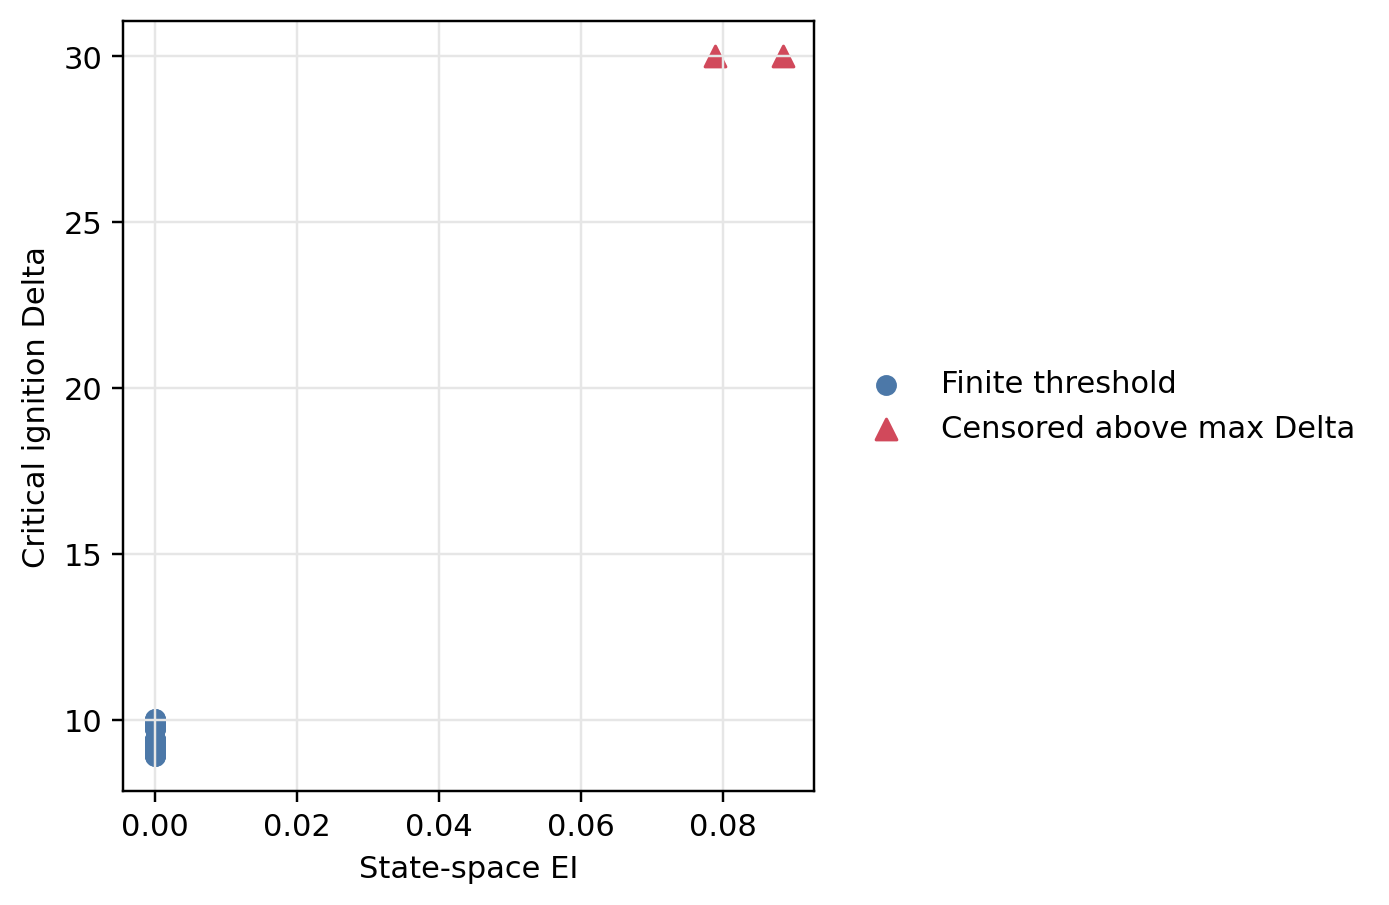

stratum /Users/yangmingzhe/Desktop/code/github/EISyn/exp/network_revival/figures/fig5l_state_wout5p0_win20p0_tau20p0_n10000_seed42/threshold_by_ei_stratum.png /Users/yangmingzhe/Desktop/code/github/EISyn/exp/network_revival/figures/fig5l_state_wout5p0_win20p0_tau20p0_n10000_seed42/threshold_by_ei_stratum.pdf


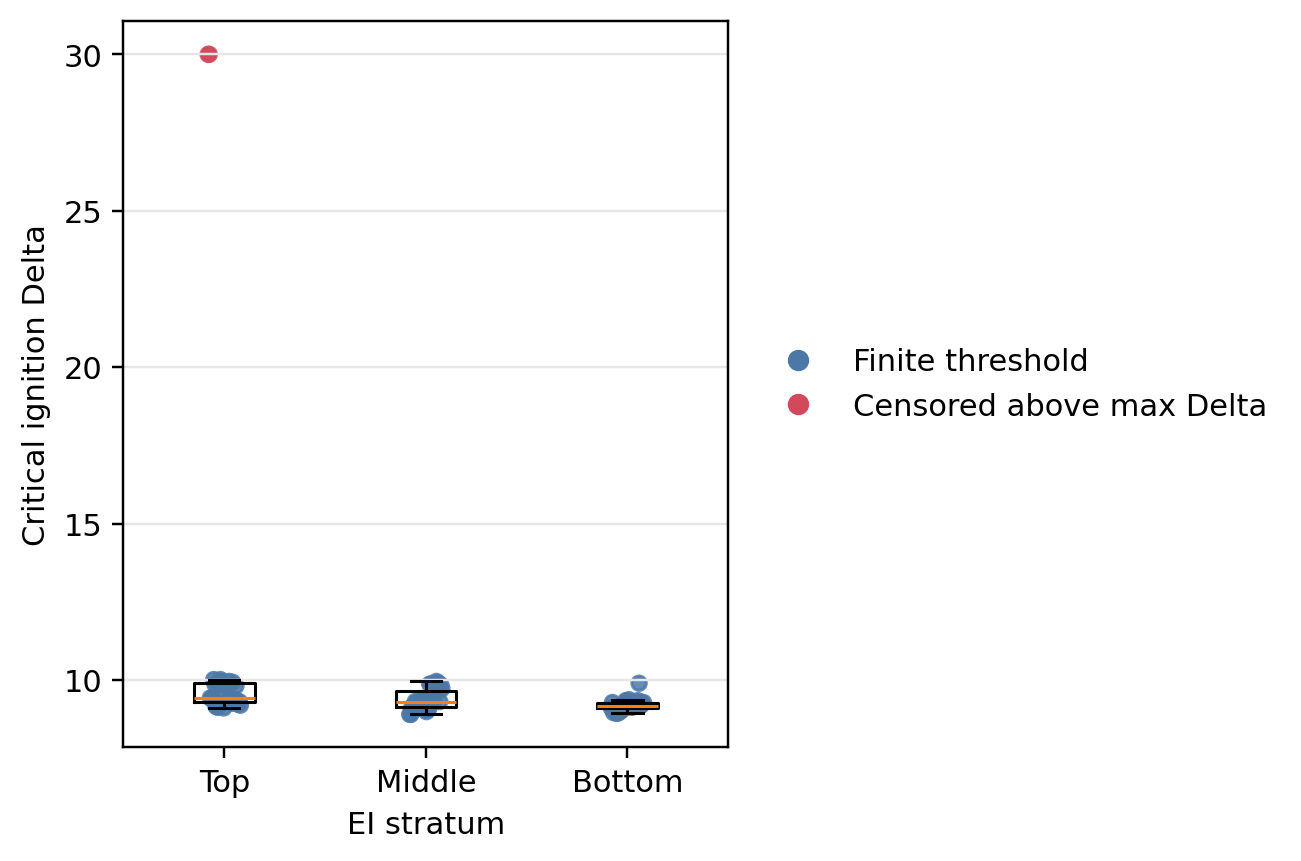

rank_curve /Users/yangmingzhe/Desktop/code/github/EISyn/exp/network_revival/figures/fig5l_state_wout5p0_win20p0_tau20p0_n10000_seed42/ei_rank_threshold_curve.png /Users/yangmingzhe/Desktop/code/github/EISyn/exp/network_revival/figures/fig5l_state_wout5p0_win20p0_tau20p0_n10000_seed42/ei_rank_threshold_curve.pdf


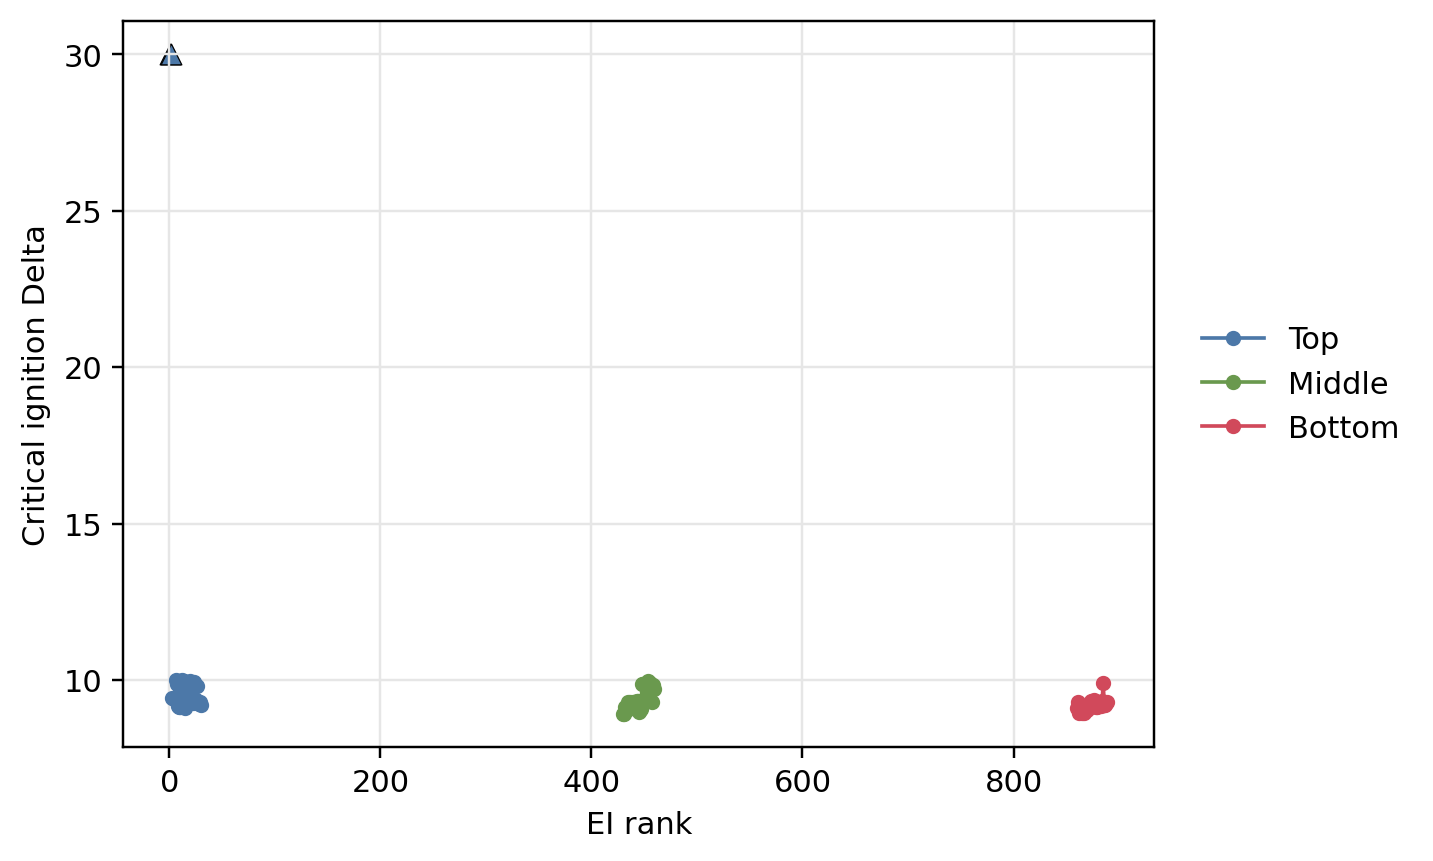


Finite ignition thresholds were found for **88 / 90** sampled nodes; the censored rate is **2.22%**.
Spearman(EI, critical Delta) is **nan** with p=nan; a negative value would support the interpretation that higher EI nodes are easier to ignite.
Median effective Delta by EI stratum is top=9.42, middle=9.32, bottom=9.18, with censored nodes displayed at the configured max Delta=30.


In [6]:
threshold_figure_paths = plot_ignition_threshold_report(threshold_result, ignition_config, FIGURE_DIR)
for name, (png_path, pdf_path) in image_paths_with_pdf(threshold_figure_paths).items():
    print(name, png_path, pdf_path)
    display(Image(filename=str(png_path)))

medians = ', '.join(
    f'{label}={value:.2f}'
    for label, value in threshold_stats['stratum_medians'].items()
    if pd.notna(value)
)
display(Markdown(f'''
Finite ignition thresholds were found for **{threshold_stats['finite_count']} / {threshold_stats['total_count']}** sampled nodes; the censored rate is **{threshold_stats['censored_rate']:.2%}**.
Spearman(EI, critical Delta) is **{threshold_stats['spearman_r']:.3f}** with p={threshold_stats['spearman_p']:.3g}; a negative value would support the interpretation that higher EI nodes are easier to ignite.
Median effective Delta by EI stratum is {medians}, with censored nodes displayed at the configured max Delta={ignition_config.delta_high:g}.
'''))


## Pair state-space synergy

Random unordered node pairs are scored by lifted source-side PEID synergy against the same final whole-system state target used above.


In [7]:
pair_synergy_result = run_state_space_pair_synergy(pair_synergy_config, force_recompute=FORCE_RECOMPUTE)
pair_synergy_stats = summarize_pair_synergy_result(pair_synergy_result, top_k=30)

print('Pair synergy CSV:', pair_synergy_result['cache_paths']['summary_csv'])
print('Samples NPZ:', pair_synergy_result['cache_paths']['samples_npz'])
print('Manifest:', pair_synergy_result['cache_paths']['manifest_json'])

display(pair_synergy_stats['top_pairs'][['pair_i', 'pair_j', 'community_i', 'community_j', 'joint_ei', 'synergy', 'synergy_ratio', 'rank_synergy']])


State-space pair synergy: 200 pairs from n=889
Pair synergy CSV: /Users/yangmingzhe/Desktop/code/github/EISyn/results/network_revival_state_space_pair_synergy/fig5l_state_wout5p0_win20p0_tau20p0_n10000_seed42_pairs200_seed42/state_space_pair_synergy.csv
Samples NPZ: /Users/yangmingzhe/Desktop/code/github/EISyn/results/network_revival_state_space_pair_synergy/fig5l_state_wout5p0_win20p0_tau20p0_n10000_seed42_pairs200_seed42/state_space_pair_synergy_samples.npz
Manifest: /Users/yangmingzhe/Desktop/code/github/EISyn/results/network_revival_state_space_pair_synergy/fig5l_state_wout5p0_win20p0_tau20p0_n10000_seed42_pairs200_seed42/manifest.json


,pair_i,pair_j,community_i,community_j,joint_ei,synergy,synergy_ratio,rank_synergy
0,3,248,M1,M1,0.0,0.0,0.0,1
1,10,140,M1,M1,0.0,0.0,0.0,2
2,13,710,M1,M2,0.0,0.0,0.0,3
3,15,493,M1,M2,0.0,0.0,0.0,4
4,16,633,M1,M2,0.0,0.0,0.0,5


rank_top /Users/yangmingzhe/Desktop/code/github/EISyn/exp/network_revival/figures/fig5l_state_wout5p0_win20p0_tau20p0_n10000_seed42/state_space_pair_synergy_rankings.png /Users/yangmingzhe/Desktop/code/github/EISyn/exp/network_revival/figures/fig5l_state_wout5p0_win20p0_tau20p0_n10000_seed42/state_space_pair_synergy_rankings.pdf


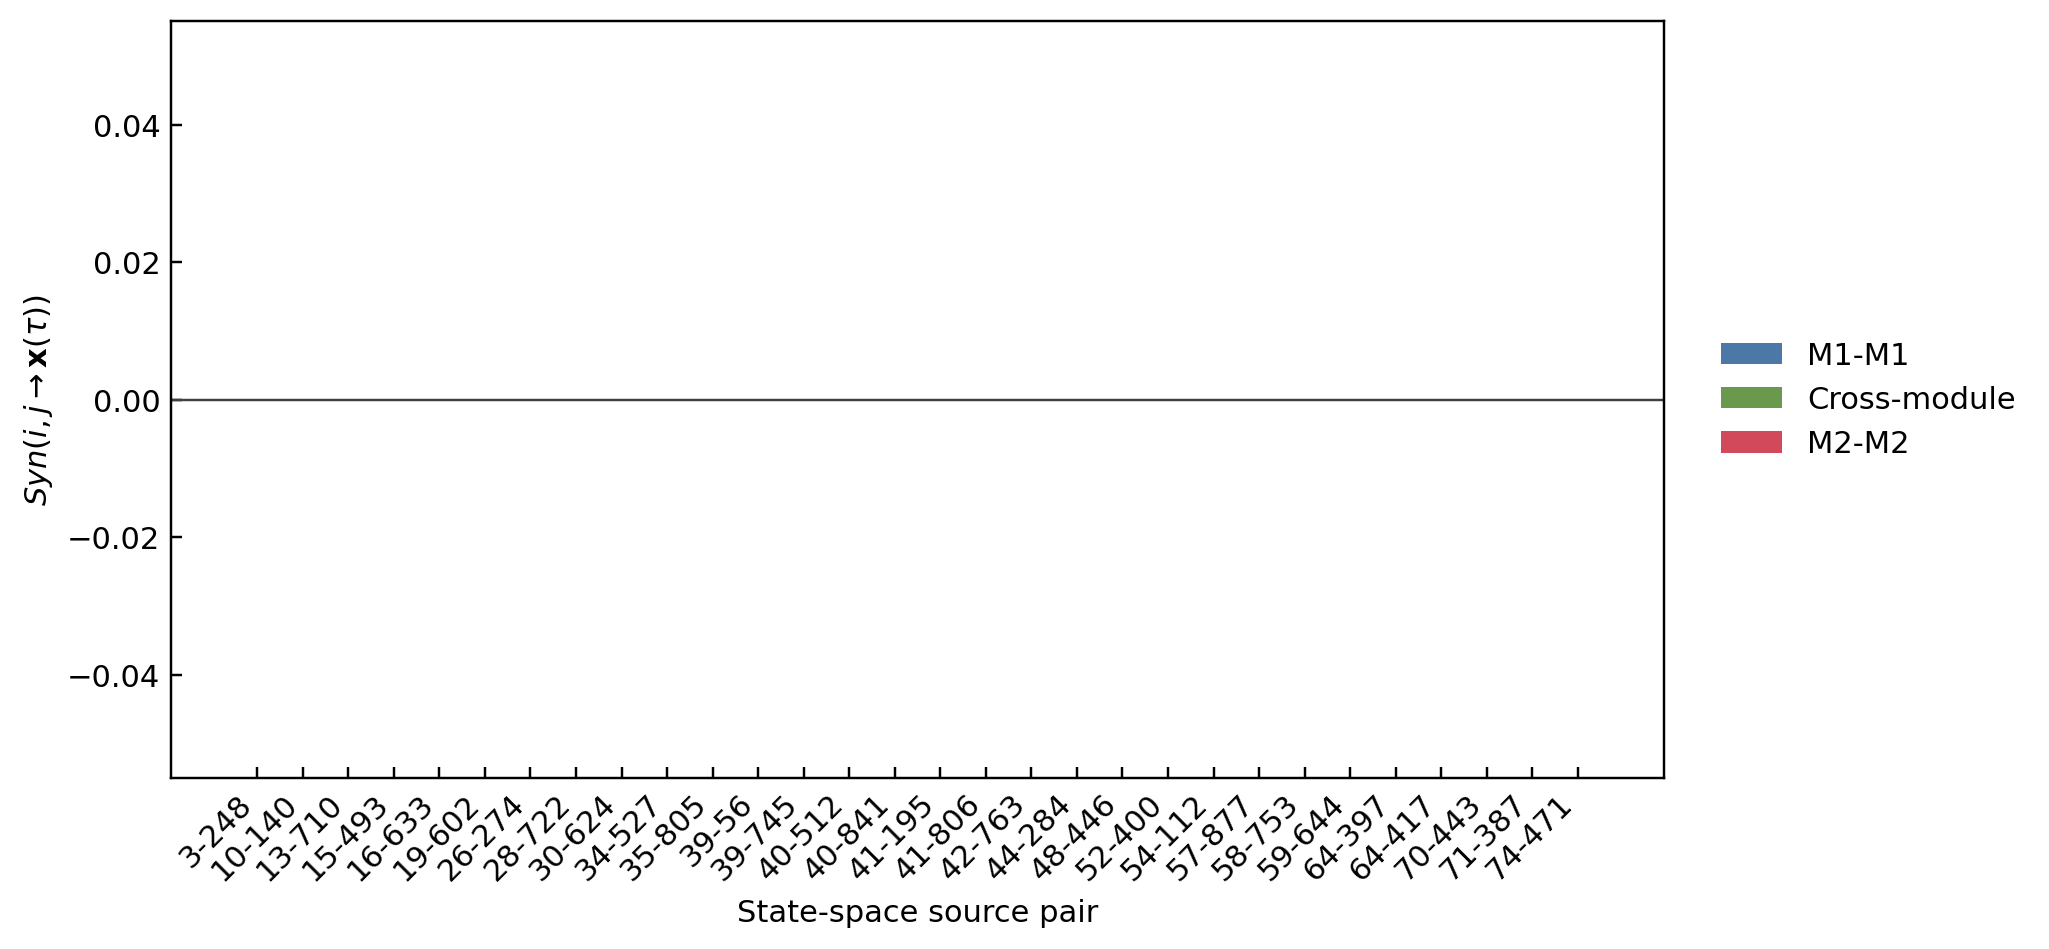


The median sampled pair synergy is **0**, and **0.0%** of sampled pairs have positive signed synergy.
The next section tests whether these high-synergy pairs reduce equal-split co-ignition cost relative to the better singleton baseline.


In [8]:
pair_synergy_figure_paths = plot_pair_synergy_report(pair_synergy_result, FIGURE_DIR, top_k=30)
for name, (png_path, pdf_path) in image_paths_with_pdf(pair_synergy_figure_paths).items():
    print(name, png_path, pdf_path)
    display(Image(filename=str(png_path)))

display(Markdown(f'''
The median sampled pair synergy is **{pair_synergy_stats['median_synergy']:.4g}**, and **{pair_synergy_stats['positive_rate']:.1%}** of sampled pairs have positive signed synergy.
The next section tests whether these high-synergy pairs reduce equal-split co-ignition cost relative to the better singleton baseline.
''' ))


## Pair co-ignition cost validation

Each pair is ignited with equal split `delta_i = delta_j = C/2`; the reported cost is the smallest total `C` that recovers both modules.


In [9]:
pair_cost_result = run_pair_ignition_cost_experiment(
    pair_ignition_config,
    pair_synergy_csv=PAIR_SYNERGY_CSV,
    force_recompute=FORCE_RECOMPUTE,
)
pair_cost_stats = summarize_pair_ignition_cost_result(pair_cost_result, pair_ignition_config)
pair_cost_df = pair_cost_stats['costs']

print('Pair cost CSV:', pair_cost_result['cache_paths']['cost_csv'])
print('Samples NPZ:', pair_cost_result['cache_paths']['samples_npz'])
print('Manifest:', pair_cost_result['cache_paths']['manifest_json'])

display(pair_cost_df[['pair_i', 'pair_j', 'rank_synergy', 'synergy', 'threshold_status', 'effective_total_cost', 'single_min_cost', 'cost_saving', 'cost_saving_ratio']].head(20))
display(pd.DataFrame({
    'metric': ['finite_count', 'total_count', 'censored_rate', 'spearman_synergy_cost', 'spearman_synergy_saving', 'median_cost_saving'],
    'value': [
        pair_cost_stats['finite_count'],
        pair_cost_stats['total_count'],
        pair_cost_stats['censored_rate'],
        pair_cost_stats['spearman_synergy_cost'],
        pair_cost_stats['spearman_synergy_saving'],
        pair_cost_stats['median_cost_saving'],
    ],
}))


Pair ignition cost 1/200: (3, 248)
Pair ignition cost 2/200: (10, 140)
Pair ignition cost 3/200: (13, 710)
Pair ignition cost 4/200: (15, 493)
Pair ignition cost 5/200: (16, 633)
Pair ignition cost 6/200: (19, 602)
Pair ignition cost 7/200: (26, 274)
Pair ignition cost 8/200: (28, 722)
Pair ignition cost 9/200: (30, 624)
Pair ignition cost 10/200: (34, 527)
Pair ignition cost 11/200: (35, 805)
Pair ignition cost 12/200: (39, 56)
Pair ignition cost 13/200: (39, 745)
Pair ignition cost 14/200: (40, 512)
Pair ignition cost 15/200: (40, 841)
Pair ignition cost 16/200: (41, 195)
Pair ignition cost 17/200: (41, 806)
Pair ignition cost 18/200: (42, 763)
Pair ignition cost 19/200: (44, 284)
Pair ignition cost 20/200: (48, 446)
Pair ignition cost 21/200: (52, 400)
Pair ignition cost 22/200: (54, 112)
Pair ignition cost 23/200: (57, 877)
Pair ignition cost 24/200: (58, 753)
Pair ignition cost 25/200: (59, 644)
Pair ignition cost 26/200: (64, 397)
Pair ignition cost 27/200: (64, 417)
Pair ignitio

,pair_i,pair_j,rank_synergy,synergy,threshold_status,effective_total_cost,single_min_cost,cost_saving,cost_saving_ratio
0,3,248,1,0.0,finite,17.988281,8.994141,-8.994141,-1.000000
1,10,140,2,0.0,finite,18.515625,9.257812,-9.257812,-1.000000
2,13,710,3,0.0,finite,17.988281,8.994141,-8.994141,-1.000000
3,15,493,4,0.0,finite,18.691406,9.345703,-9.345703,-1.000000
4,16,633,5,0.0,finite,18.046875,9.023438,-9.023438,-1.000000
5,19,602,6,0.0,finite,18.281250,9.169922,-9.111328,-0.993610
6,26,274,7,0.0,finite,18.046875,9.023438,-9.023438,-1.000000
7,28,722,8,0.0,finite,17.695312,8.847656,-8.847656,-1.000000
8,30,624,9,0.0,finite,18.164062,9.082031,-9.082031,-1.000000
9,34,527,10,0.0,finite,18.339844,9.169922,-9.169922,-1.000000


,metric,value
0,finite_count,200.000000
1,total_count,200.000000
2,censored_rate,0.000000
3,spearman_synergy_cost,-0.096185
4,spearman_synergy_saving,0.098017
5,median_cost_saving,-9.023438


synergy_vs_cost /Users/yangmingzhe/Desktop/code/github/EISyn/exp/network_revival/figures/fig5l_state_wout5p0_win20p0_tau20p0_n10000_seed42/pair_synergy_vs_total_cost.png /Users/yangmingzhe/Desktop/code/github/EISyn/exp/network_revival/figures/fig5l_state_wout5p0_win20p0_tau20p0_n10000_seed42/pair_synergy_vs_total_cost.pdf


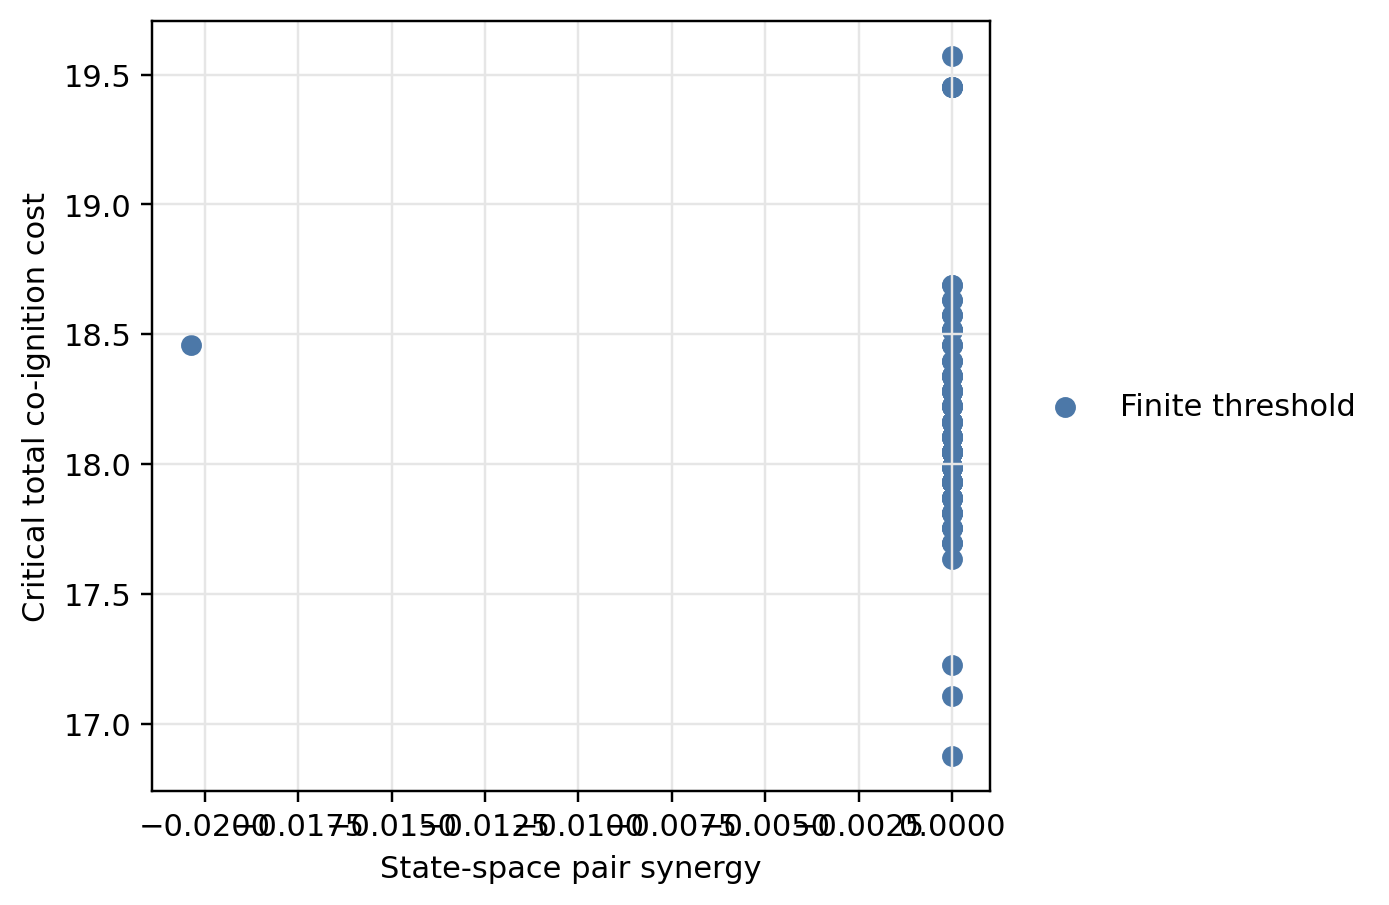

synergy_vs_saving /Users/yangmingzhe/Desktop/code/github/EISyn/exp/network_revival/figures/fig5l_state_wout5p0_win20p0_tau20p0_n10000_seed42/pair_synergy_vs_cost_saving_ratio.png /Users/yangmingzhe/Desktop/code/github/EISyn/exp/network_revival/figures/fig5l_state_wout5p0_win20p0_tau20p0_n10000_seed42/pair_synergy_vs_cost_saving_ratio.pdf


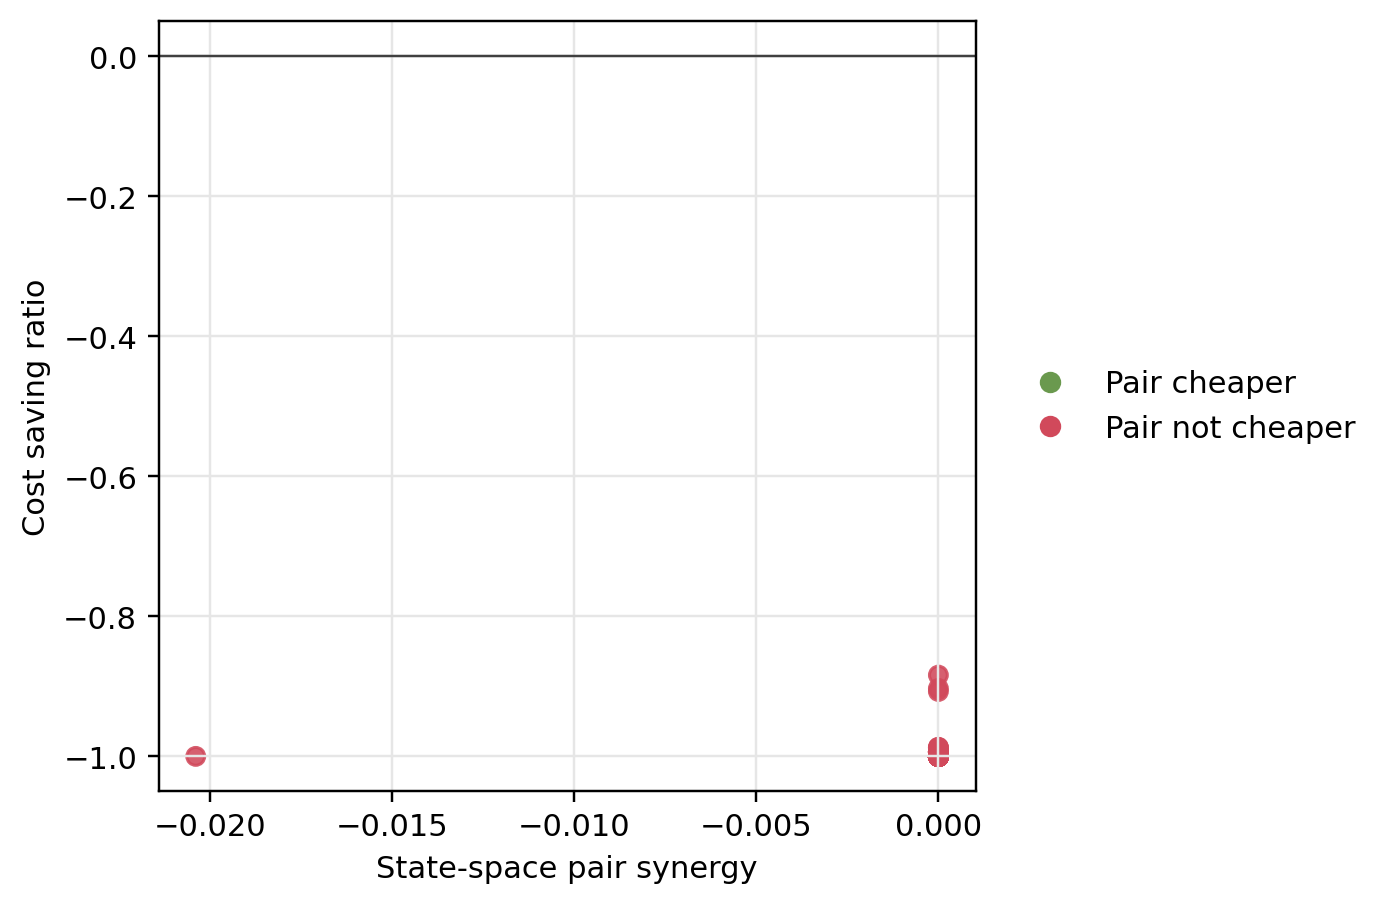


Finite pair co-ignition thresholds were found for **200 / 200** sampled pairs; censored pairs are displayed at max total cost 60.
Spearman(pair synergy, critical total cost) is **-0.096**; Spearman(pair synergy, cost saving) is **0.098**.
Positive cost saving means the equal-split pair intervention needs less total input than the better of the two singleton interventions.


In [10]:
pair_cost_figure_paths = plot_pair_ignition_cost_report(pair_cost_result, pair_ignition_config, FIGURE_DIR)
for name, (png_path, pdf_path) in image_paths_with_pdf(pair_cost_figure_paths).items():
    print(name, png_path, pdf_path)
    display(Image(filename=str(png_path)))

display(Markdown(f'''
Finite pair co-ignition thresholds were found for **{pair_cost_stats['finite_count']} / {pair_cost_stats['total_count']}** sampled pairs; censored pairs are displayed at max total cost {pair_ignition_config.cost_high:g}.
Spearman(pair synergy, critical total cost) is **{pair_cost_stats['spearman_synergy_cost']:.3f}**; Spearman(pair synergy, cost saving) is **{pair_cost_stats['spearman_synergy_saving']:.3f}**.
Positive cost saving means the equal-split pair intervention needs less total input than the better of the two singleton interventions.
''' ))
